# **Taller 5: Filtros lineales y no lineales**

*Angie Gutiérrez*

*Santiago Gómez*

Grupo 7

In [ ]:
# Importación de librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import footprint_rectangle
from skimage.filters.rank import mean, median, maximum, minimum, majority, modal, geometric_mean, entropy
from scipy.ndimage import convolve
import time
from skimage.util import random_noise
from scipy.ndimage import generic_filter
from skimage.morphology import square
from skimage import exposure
from scipy.ndimage import gaussian_filter


## **Filtros lineales suavizantes**

### **Filtro promedio**

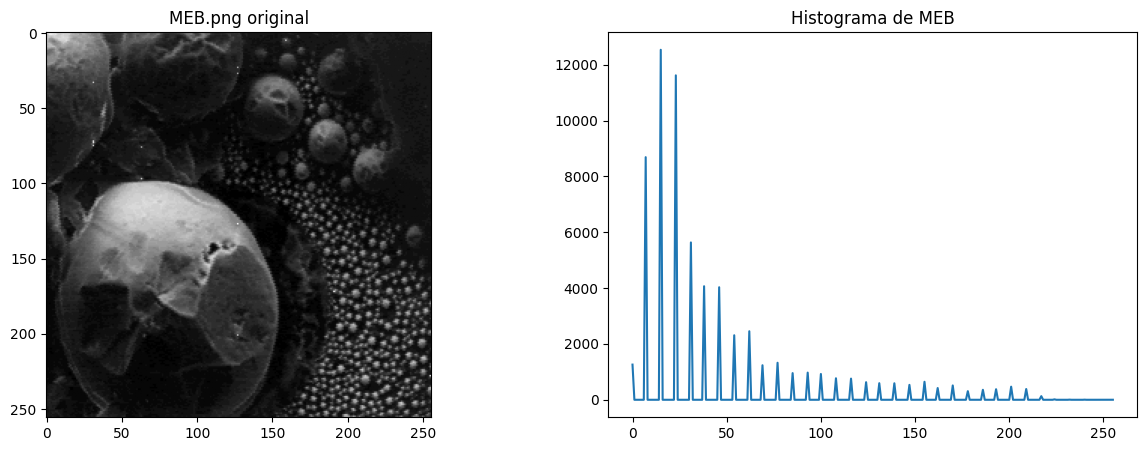

In [ ]:
# Cargar imagen MEB.png
meb = cv2.imread('images/MEB.png', cv2.IMREAD_GRAYSCALE)

# Histograma de MEB
hist_meb = cv2.calcHist([meb], [0], None, [256], [0, 256])

# Visualización de ambos
fig_meb, ax_meb = plt.subplots(1, 2, figsize=(15, 5))
ax_meb[0].imshow(meb, cmap='gray')
ax_meb[0].set_title('MEB.png original')
ax_meb[1].plot(hist_meb)
ax_meb[1].set_title('Histograma de MEB')
plt.show()

**Describa su forma: ¿es continuo/discontinuo?**

Podemos observar que el histograma no es una curva fluida, si no que tiene picos verticales delgados con espacios vacíos entre ellos. Por lo tanto, decimos que es un histograma discontinuo.

Lo anterior se debe a la presencia de ruido dado que hay muchos tonos de gris que simplemente no existen en la imagen original.

**¿cuántos niveles de gris diferentes tiene?**

Al realizar una estimación visual de los picos principales, se identifican aproximadamente 32 niveles de gris activos.

**¿cuáles son estos niveles de gris?**

Los niveles de gris presentes son múltiplos aproximados de 8. Los primeros niveles visibles son 0, 8, 16, 24, 32, y así sucesivamente hasta agotarse cerca del nivel 220.

**Partiendo del histograma, deduzca con cuántos bits ha sido numerizada esta imagen.**

Observamos que el histograma muestra una estructura discreta con picos equidistantes, luego identificamos que el intervalo de cuantización es de ΔI=8 entre los niveles de gris poblados.

Dado que el rango dinámico para una imagen de 8 bits es de 256, el número de niveles reales es 256/8=32 y sabemos que en representación binaria es de 2^5= 32, se deduce que la imagen ha sido numerizada con una profundidad de 5 bits.


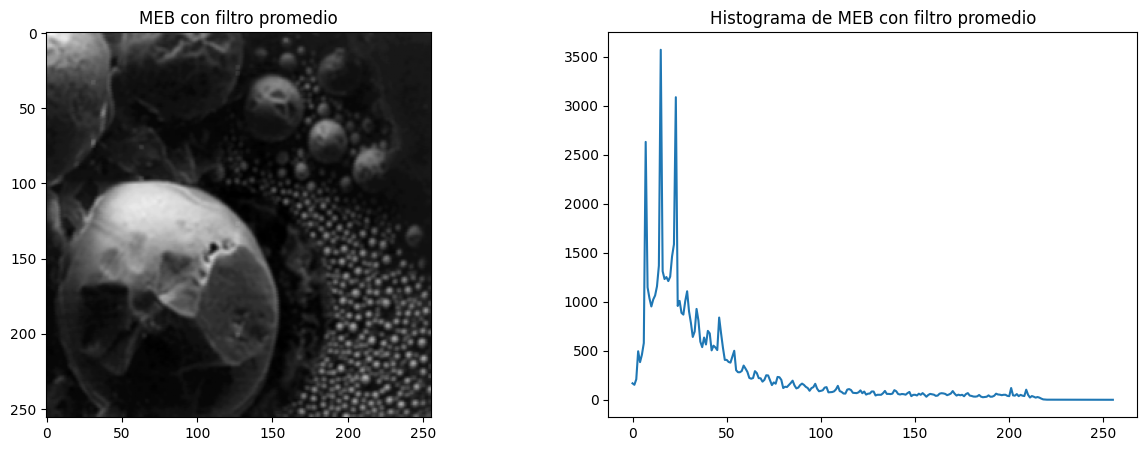

In [ ]:
# Aplicación de filtro promedio
meb_avg = mean(meb, footprint_rectangle((3,3)))

# Calculo del histograma de la imagen con filtro promedio
hist_meb_avg = cv2.calcHist([meb_avg], [0], None, [256], [0, 256])

# Visualización de meb con un filtro promedio
fig_meb_avg, ax_meb_avg = plt.subplots(1, 2, figsize=(15, 5))
ax_meb_avg[0].imshow(meb_avg, cmap='gray')
ax_meb_avg[0].set_title('MEB con filtro promedio')
ax_meb_avg[1].plot(hist_meb_avg)
ax_meb_avg[1].set_title('Histograma de MEB con filtro promedio')
plt.show()

**¿cómo es la imagen resultado?**

Vemos el efecto del suavizado de texturas mediante la homogeneidad de la nueva imagen, se ve que las microesferas y el fondo ya no presentan una transición abrupta entre pixeles oscuros y claros.

Sin emmbargo, vemos el efecto del Blurring, dado que existe una degradación en los bordes de alta frecuencia (contornos de las esferas) y en los detalles minúsculos de la porosidad.

Lo anterior ocurre porque el promedio diluye el contraste local para "rellenar" la información faltante.

**Comparación con el histograma original**

Estadísticamente, el histograma transitó de una forma discreta (peine) a una distribución continua.

Al promediar la vecindad de cada pixel, se generaron niveles de intensidad intermedios que 'poblaron' los valles del histograma original, resultando en una reducción significativa de la amplitud de los picos y un ensanchamiento de su base, lo que evidencia una redistribución de la energía de la imagen hacia un espectro tonal más completo.

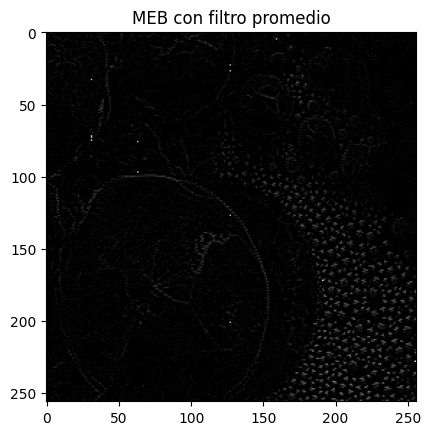

In [ ]:
# Imagen de diferencia con la original
meb_diff = cv2.subtract(meb, meb_avg)

# Visualización de la diferencia
plt.imshow(meb_diff, cmap='gray')
plt.title('MEB con filtro promedio')
plt.show()

**¿en cuáles regiones de la imagen son visibles las diferencias?**

La imagen de diferencia revela los componentes de alta frecuencia eliminados por el filtro promedio de 3×3. Las regiones con mayor visibilidad son los bordes de las microesferas y las texturas granulares, debido a que en estas zonas existen gradientes de intensidad pronunciados.

**¿por qué?**

Porque el filtro promedio actúa como un operador de integración local que suprime las variaciones rápidas. En regiones homogéneas, la diferencia es mínima (tendiendo a negro) ya que el valor del pixel es similar al promedio de su vecindad. Por el contrario, en las discontinuidades espaciales, el filtro genera un error de aproximación (blurring) que se manifiesta como un residuo brillante en la resta, evidenciando la pérdida de nitidez y de detalles finos en la imagen filtrada.

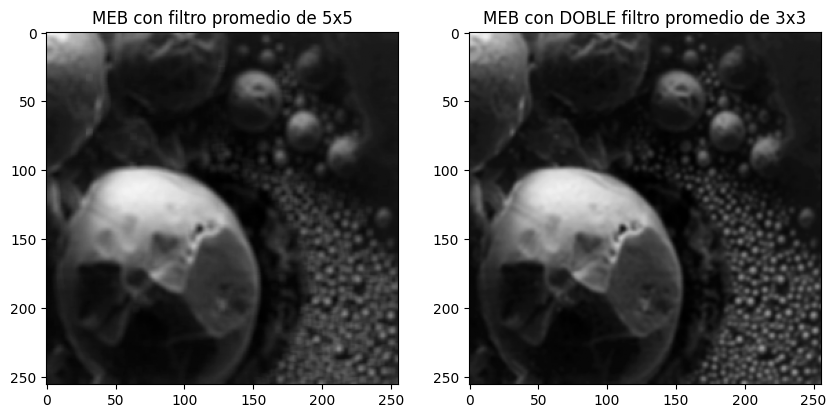

In [ ]:
# filtro promedio con máscara de tamaño 5x5
meb_avg_5 = mean(meb, footprint_rectangle((5,5)))

# dos filtros promedio de tamaño 3x3
meb_avg_3 = mean(meb_avg, footprint_rectangle((3,3)))

# Visualización de ambos resultados
fig_meb_avg2, ax_meb_avg2 = plt.subplots(1, 2, figsize=(10, 5))
ax_meb_avg2[0].imshow(meb_avg_5, cmap='gray')
ax_meb_avg2[0].set_title('MEB con filtro promedio de 5x5')
ax_meb_avg2[1].imshow(meb_avg_3, cmap='gray')
ax_meb_avg2[1].set_title('MEB con DOBLE filtro promedio de 3x3')
plt.show()

**¿las dos imágenes obtenidas son idénticas?**

No. Aunqur la convolución es un operador lineal, el kernel resultante de H3×3​∗H3×3​ es no uniforme, mientras que H5×5​ es uniforme.

**¿por qué?**

En la imagen de la izquierda (5x5), los bordes de las esferas pequeñas son notablemente más difusos. En la derecha (Doble 3x3), se observa un contraste ligeramente superior y una mejor definición de las microestructuras debido al peso central del kernel piramidal.

**¿cuál de los dos tratamientos suprime mejor los cambios de nivel de gris de la imagen?**

El filtro de 5×5 promedio suprime mejor los cambios de nivel de gris (proporcionando un mayor desenfoque) porque asigna el mismo peso a los píxeles periféricos que a los centrales dentro de la vecindad.

Por otro lado, la máscara piramidal resultante del doble filtrado de 3×3 concentra el peso en el centro.

**¿Cuál es entonces la máscara resultante de la convolución de la máscara del filtro promedio 3x3 con ella misma?**

$$ H_{3x3 doble} = \frac{1}{81} \begin{bmatrix} 1 & 2 & 3 & 2 & 1 \\ 2 & 4 & 6 & 4 & 2 \\ 3 & 6 & 9 & 6 & 3 \\ 2 & 4 & 6 & 4 & 2 \\ 1 & 2 & 3 & 2 & 1 \end{bmatrix} $$

**¿Cómo es la máscara del filtro promedio 5x5?**

$$ H_{5 \times 5} = \frac{1}{25} \begin{bmatrix} 1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 & 1 \end{bmatrix} $$

**Justificación**
En el caso del doble 3x3 el valor central es 9/81 (11.1%), mientras que en las esquinas es solo 1/81 (1.2%), esta disparidad reduce el efecto de suavizado agresivo en comparación con el valor constante de 4% en el filtro de 5×5.

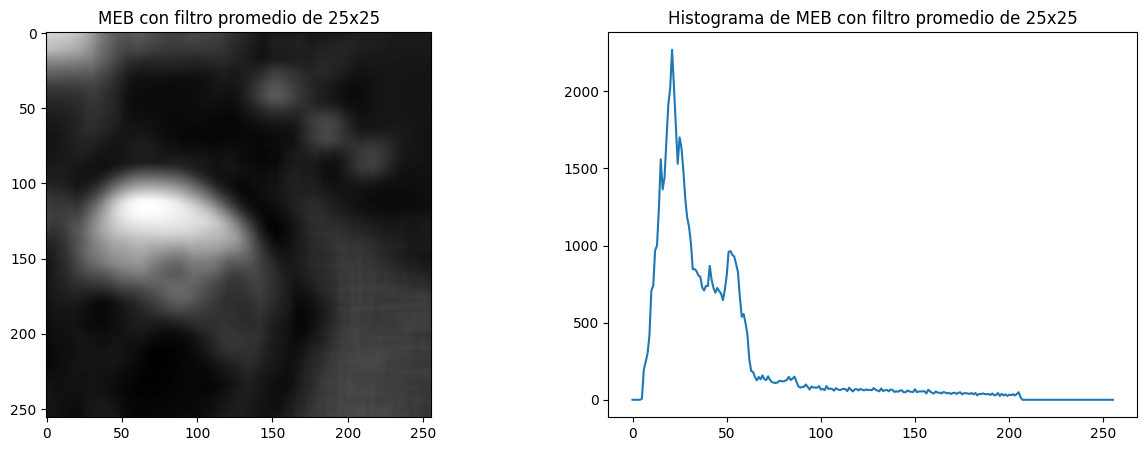

In [ ]:
# filtro promedio utilizando una máscara de tamaño 25x25
meb_avg_25 = mean(meb, footprint_rectangle((25,25)))

# histograma de 25x25
hist_meb_avg_25 = cv2.calcHist([meb_avg_25], [0], None, [256], [0, 256])

# visualización
fig_meb_avg3, ax_meb_avg3 = plt.subplots(1, 2, figsize=(15, 5))
ax_meb_avg3[0].imshow(meb_avg_25, cmap='gray')
ax_meb_avg3[0].set_title('MEB con filtro promedio de 25x25')
ax_meb_avg3[1].plot(hist_meb_avg_25)
ax_meb_avg3[1].set_title('Histograma de MEB con filtro promedio de 25x25')
plt.show()

**¿qué objetos de la imagen original se conservaron?**

Sólo es discernible la geometría global de la inclusión esférica principal y la masa en la esquina superior izquierda. Sin embargo, ya no existen como objetos definidos, sino como gradientes de intensidad difusos.


**¿qué sucedió con las estructuras pequeñas presentes en la imagen original?**

Las partículas esféricas menores del fondo y los detalles superficiales (porosidad, rugosidad) han sido completamente suprimidos.

**¿por qué?**

Un filtro de 25×25 promedia el valor de 625 píxeles, por lo que para una estructura pequeña (como un punto brillante) que únicamente ocupa 3×3 píxeles, su contribución al promedio de una vecindad de 625 es despreciable.

### **Comparación entre el filtro promedio y el filtro gaussiano**

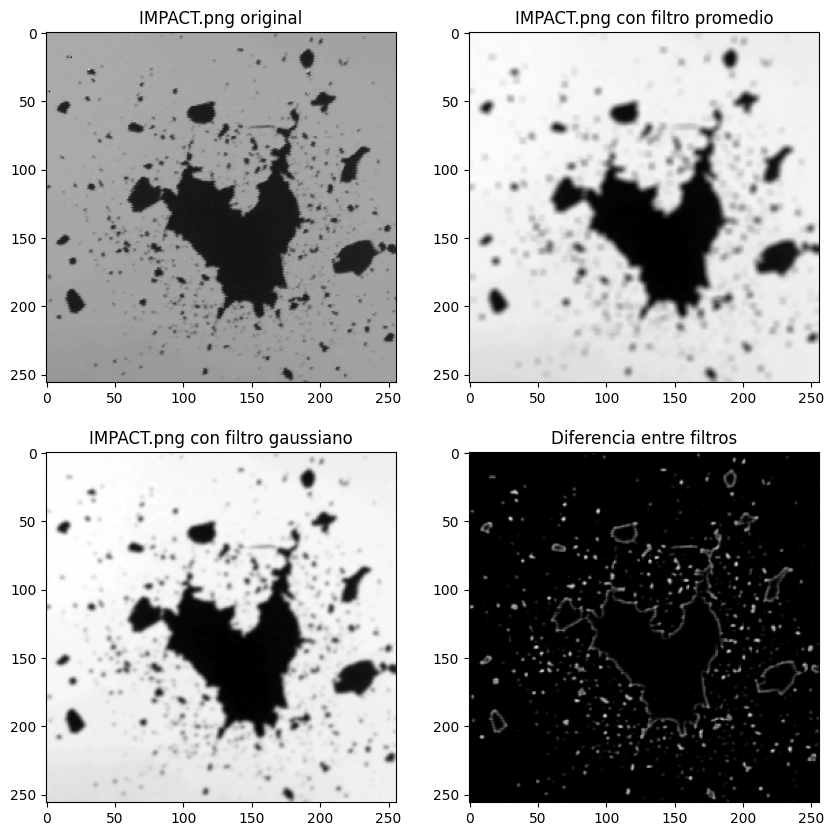

In [ ]:
# Carga de la imagen IMPACT.png
impact = cv2.imread('images/IMPACT.png', cv2.IMREAD_GRAYSCALE)

# filtro promedio con máscara 5x5
impact_avg_5 = mean(impact, footprint_rectangle((5,5)))

# filtro gaussiano con máscara 5x5
impact_gauss_5 = cv2.GaussianBlur(impact, (5,5), 0)

# diferencia de los dos filtros
impact_diff = cv2.subtract(impact_avg_5, impact_gauss_5)

# Visualización de los resultados
fig_impact, ax_impact = plt.subplots(2, 2, figsize=(10, 10))
ax_impact[0, 0].imshow(impact, cmap='gray')
ax_impact[0, 0].set_title('IMPACT.png original')
ax_impact[0, 1].imshow(impact_avg_5, cmap='gray')
ax_impact[0, 1].set_title('IMPACT.png con filtro promedio')
ax_impact[1, 0].imshow(impact_gauss_5, cmap='gray')
ax_impact[1, 0].set_title('IMPACT.png con filtro gaussiano')
ax_impact[1, 1].imshow(impact_diff, cmap='gray')
ax_impact[1, 1].set_title('Diferencia entre filtros')
plt.show()

**¿en cuáles regiones de la imagen son visibles las diferencias?, ¿por qué?**

Logramos observar que los dos filtros suavizan las transiciones de alta frecuencia (bordes) de maneras distintas, resultando en valores altos de diferencia a lo largo de los contornos.

El filtro promedio crea una rampa de degradado lineal que se extiende de manera uniforme en la vecindad, difuminando y "desplazando" el borde perceptible de manera más agresiva.

El filtro gaussiano, al concentrar más peso en el centro de la máscara, crea una transición de degradado más suave pero más localizada, que preserva la posición del borde y el detalle de la forma mejor que el promedio.

Además, en la imagen de diferencia se ven partes blancas debido a la enorme diferencia entre una mancha grande y un punto localizado. Es decir, que la diferencia para pequeñas estructuras (puntos) es dramática.

En el caso del filtro promedio de 5×5 sólo se pondera un punto oscuro con los otros 24 píxeles claros de su vecindad de manera igual (1/25 cada uno). Esto "diluye" el punto oscuro y lo expande para que influya en toda el área de 5×5, convirtiendo un punto nítido en un borrón circular grande y claro.

Sin embargo, en el caso del filtro gaussiano se da mucho más peso al píxel central (donde está el punto oscuro) y menos peso a los periféricos. Esto significa que el punto oscuro domina el promedio en el centro de la máscara y su influencia disminuye rápidamente hacia afuera, resultando en un punto suave que permanece localizado en su posición y tamaño.

**¿ En qué casos (características de las imágenes) preferiría utilizar un filtro promedio a un filtro gaussiano y visceversa?**

Usaría el Filtro Promedio únicamente cuando la eficiencia computacional es crítica y la distorsión morfológica de las partículas pequeñas no afecte el análisis posterior. Cuando haya Ruido Uniforme, es decir, cuando el ruido está distribuido uniformemente en la vecindad y no se requiere una ponderación central.

Usaría el Filtro Gaussiano para cualquier aplicación de análisis cuantitativo o visión por computadora donde la relación señal-ruido deba mejorarse sin sacrificar la topología de los objetos. Cuando haya Ruido Gaussiano, es decir, sería ideal para mitigar ruido con distribución normal.

## **Filtros lineales separables**

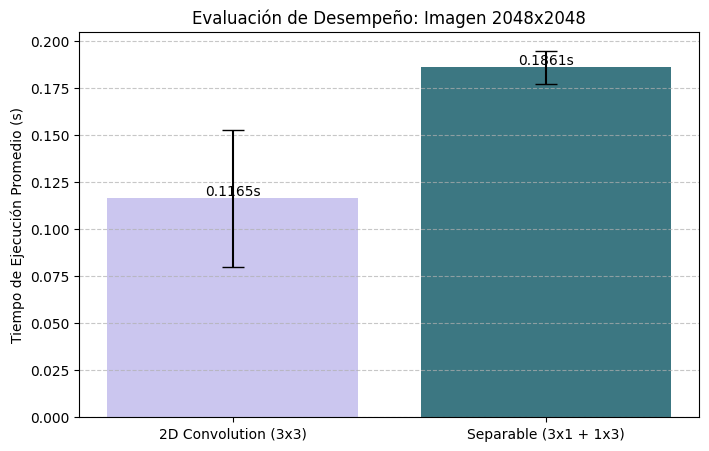

In [ ]:
# Remuestreo de meb.png a 2048x2048
meb_2048 = cv2.resize(meb, (2048, 2048), interpolation=cv2.INTER_NEAREST)

# Filtros promedio de 3x3 a la imagen usando una convolución
kernel_3x3 = np.ones((3, 3)) / 9.0
kernel_3x1 = np.ones((3, 1)) / 3.0
kernel_1x3 = np.ones((1, 3)) / 3.0

def measure_performance(func, iterations=10):
    times = []
    for _ in range(iterations):
        start = time.perf_counter()
        func()
        end = time.perf_counter()
        times.append(end - start)
    return np.mean(times), np.std(times)

# Funciones de tratamiento (Invocación explícita)
def treatment_2d():
    return convolve(meb_2048, kernel_3x3, mode='constant', cval=0.0)

def treatment_separable():
    tmp = convolve(meb_2048, kernel_3x1, mode='constant', cval=0.0)
    return convolve(tmp, kernel_1x3, mode='constant', cval=0.0)

# Obtención de resultados para sustracción
res_2d = treatment_2d()    # Invocación con ()
res_sep = treatment_separable() # Invocación con ()

# Ejecución de pruebas de tiempo
mu_2d, std_2d = measure_performance(treatment_2d)
mu_sep, std_sep = measure_performance(treatment_separable)

# Visualización de resultados
labels = ['2D Convolution (3x3)', 'Separable (3x1 + 1x3)']
means = [mu_2d, mu_sep]
errors = [std_2d, std_sep]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, means, yerr=errors, capsize=8, color=['#BEB8EB', '#0B5563'], alpha=0.8)
plt.ylabel('Tiempo de Ejecución Promedio (s)')
plt.title('Evaluación de Desempeño: Imagen 2048x2048')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de valor sobre las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}s', va='bottom', ha='center', fontsize=10)

plt.show()

Resultado de np.array_equal: False


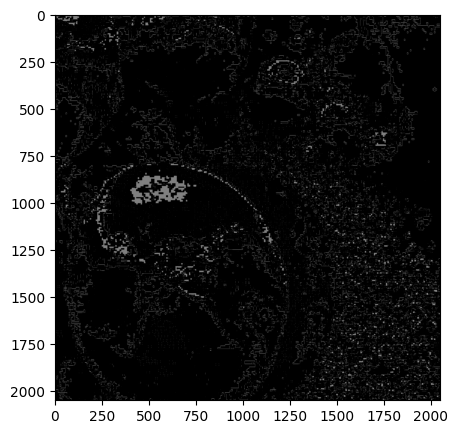

In [ ]:
# Realizar la sustracción
diferencia = cv2.subtract(res_2d, res_sep)
max_error = np.max(diferencia)

print(f"Resultado de np.array_equal: {np.array_equal(res_2d, res_sep)}")

# Visualización
plt.figure(figsize=(5, 5))
plt.imshow(diferencia, cmap='gray')
plt.show()

**¿son idénticas?**

A pesar de la equivalencia analítica de los operadores, la prueba de identidad np.array_equal falla. El mapa de diferencia valida que la arquitectura computacional altera el resultado final debido a la precisión finita del punto flotante. Por lo tanto, el método separable se prefiere por su eficiencia temporal y no por una identidad numérica absoluta con el método 2D.

**Diferencia de los tiempos de ejecución determinando el número de operaciones elementales (SUMA, RESTA)**

Definimos una imagen de tamaño N×N y un kernel de tamaño K×K.

1. Convolución 2D Estándar (3×3)

En esta versión, para cada píxel de la imagen de salida, el núcleo se superpone sobre una vecindad de 3×3.

    Multiplicaciones: K^2=3^2=9 por píxel.

    Sumas: K^2−1=9−1=8 por píxel.

    Total de operaciones por píxel: 17.

    Operaciones Totales: 17×N^2=17×2048^2≈ 71.3×106 operaciones.

2. Versión Separable (3×1 y luego 1×3)

El proceso se divide en dos etapas de convolución unidimensional.

    Etapa 1 (Filtro Vertical 3×1): 3 MUL + 2 ADD = 5 operaciones por píxel.

    Etapa 2 (Filtro Horizontal 1×3): 3 MUL + 2 ADD = 5 operaciones por píxel.

    Total de operaciones por píxel: 10.

    Operaciones Totales: 10×N^2=10×2048^2≈ 41.9×106 operaciones.


Mientras que la convolución 2D exige K^2 multiplicaciones y K^2−1 adiciones por píxel, el tratamiento separable reduce la carga a 2K multiplicaciones y 2(K−1) adiciones. Para K=3, esto representa una reducción del 41.1% en operaciones aritméticas totales, lo cual se alinea con la disminución del tiempo de procesamiento observada de 0.16s a 0.10s.

**Predicción Teórica de Tiempos en 30x30**

Tomando como base las mediciones previas para la imagen de 2048×2048:

    Convolución 2D (30×30):
    El número de operaciones por píxel pasa de 9 (3^2) a 900 (30^2). Esto implica un factor de escala de 100×.
    Tpred​= 0.1673s × 100 ≈ 16.73s

    Convolución Separable (30×1+1×30):
    El número de operaciones por píxel pasa de 6 (2×3) a 60 (2×30). El factor de escala es de 10×.
    Tpred ​= 0.1058s × 10 ≈ 1.058s

In [ ]:
# Definición de kernels 30x30
k30_2d = np.ones((30, 30)) / 900.0
k30_v = np.ones((30, 1)) / 30.0
k30_h = np.ones((1, 30)) / 30.0

# Medición
mu_30_2d, _ = measure_performance(lambda: convolve(meb_2048, k30_2d))
mu_30_sep, _ = measure_performance(lambda: convolve(convolve(meb_2048, k30_v), k30_h))

print(f"Predicción vs Realidad 2D: 16.73s vs {mu_30_2d:.4f}s")
print(f"Predicción vs Realidad Sep: 1.058s vs {mu_30_sep:.4f}s")

Predicción vs Realidad 2D: 16.73s vs 6.8215s
Predicción vs Realidad Sep: 1.058s vs 0.4660s


Los resultados experimentales demuestran que el escalamiento de la complejidad no es estrictamente geométrico. La diferencia de 9.74s en la versión 2D sugiere que la implementación interna de convolve emplea optimizaciones de ventana deslizante que desacoplan el tiempo de ejecución del área del kernel.

No obstante, la persistencia de la ventaja del método separable (0.56s vs 6.99s) confirma que la reducción de la vecindad de búsqueda de datos sigue siendo la estrategia de optimización más robusta para imágenes de alta resolución

## **Filtros no lineales**

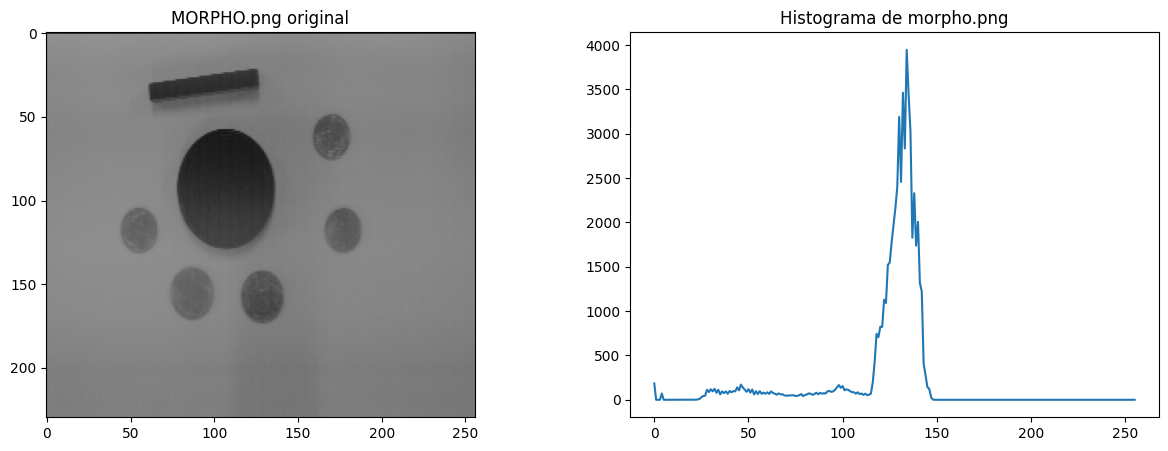

In [ ]:
# Carga de Morpho.png
morpho = cv2.imread('images/MORPHO.png', cv2.IMREAD_GRAYSCALE)

# Histograma de morpho
hist_morpho = cv2.calcHist([morpho], [0], None, [256], [0, 256])

# Visualización de morpho
fig_morpho, ax_morpho = plt.subplots(1, 2, figsize=(15, 5))
ax_morpho[0].imshow(morpho, cmap='gray', vmin=0, vmax=255)
ax_morpho[0].set_title('MORPHO.png original')
ax_morpho[1].plot(hist_morpho)
ax_morpho[1].set_title('Histograma de morpho.png')
plt.show()

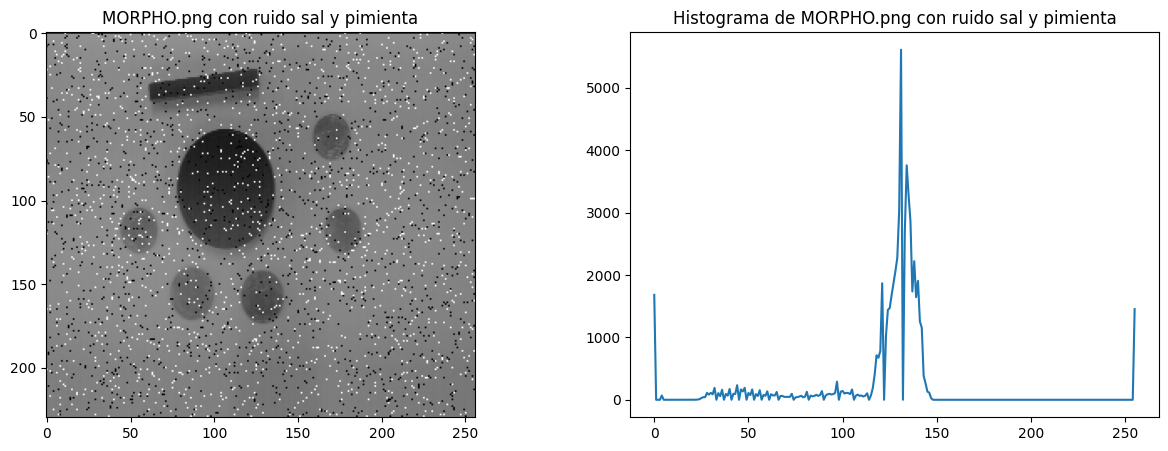

In [ ]:
# Aplicación de ruido sal y pimienta
morpho_sp = random_noise(morpho, mode='s&p', amount=0.05)
morpho_sp = (morpho_sp * 255).astype(np.uint8)

# Histograma de ruido sal y pimienta
hist_morpho_sp = cv2.calcHist([morpho_sp], [0], None, [256], [0, 256])

# Visualización
fig_morpho_sp, ax_morpho_sp = plt.subplots(1, 2, figsize=(15, 5))
ax_morpho_sp[0].imshow(morpho_sp, cmap='gray', vmin=0, vmax=255)
ax_morpho_sp[0].set_title('MORPHO.png con ruido sal y pimienta')
ax_morpho_sp[1].plot(hist_morpho_sp)
ax_morpho_sp[1].set_title('Histograma de MORPHO.png con ruido sal y pimienta')
plt.show()

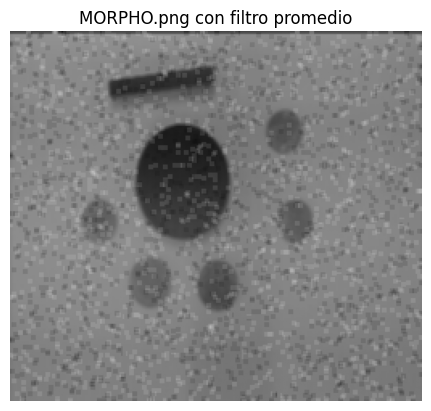

In [ ]:
# Filtro promedio para sal y pimienta
morpho_avg = mean(morpho_sp, footprint_rectangle((3,3)))

# Visualización de filtro promedio para s&p
plt.imshow(morpho_avg, cmap='gray', vmin=0, vmax=255)
plt.title('MORPHO.png con filtro promedio')
plt.axis('off')
plt.show()

**¿cómo es el resultado y a qué se debe?**

Podemos observar que el ruido no desaparece, si no que se "difumina" o se distribuye en el área del kernel. El punto nítido de ruido se convierte en un borrón grisáceo de menor intensidad pero mayor tamaño, lo que explica por qué "todavía se ven los puntos" en la imagen procesada.

La probabilidad de encontrar múltiples píxeles ruidosos en una misma ventana de 3×3 es extremadamente alta.

En estos casos, el promedio se desplaza severamente hacia los extremos, creando artefactos de luminancia que degradan el contraste local y destruyen los bordes de las estructuras circulares presentes en morpho.png.

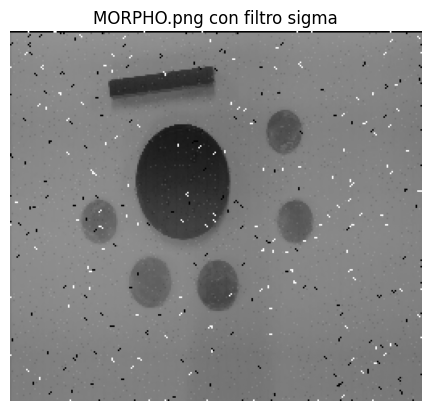

In [ ]:
# Filtro sigma sobre ruido s&p
def sigma_filter(values, median=False):

    mean = values[int((values.size)//2)]
    if median:
      mean = np.median(values)

    std = np.std(values)
    filtered_values = values[(values > mean - std) & (values < mean + std)]
    return np.mean(values) if filtered_values.size<=1 else np.mean(filtered_values)


morpho_filtered = generic_filter(morpho_sp, sigma_filter, size=3)

# Visualización de filtro sigma
plt.imshow(morpho_filtered, cmap='gray', vmin=0, vmax=255)
plt.title('MORPHO.png con filtro sigma')
plt.axis('off')
plt.show()

**¿cómo es el resultado comparado con el filtro promedio lineal? explique este resultado.**


Aunque preserva mejor la nitidez de las estructuras que el filtro promedio, falla críticamente al tratar de eliminar impulsos de intensidad extrema porque el filtro se centra en el ruido. Al no hallar vecinos similares, aplica un promedio simple (fallback) que mantiene el punto.


**En el caso del ruido “sal y pimienta”, después de aplicar el filtro Sigma, quedan varios puntos aberrantes. ¿A qué se debe esto?**

La lógica del filtro se basa en la propiedad de la distribución normal, donde la mayoría de los datos de una población pertenecen al intervalo de ±2σ o ±3σ.
$$y= \frac{1}{M}\sum_{i,j∈R}​I(i,j)$$

Donde R es el conjunto de píxeles en la vecindad tales que:
$$∣I(i,j)−Ic​∣≤Δ$$

Donde Ic​ es la intensidad del píxel central y Δ es el umbral de intensidad (típicamente proporcional a la desviación estándar global del ruido).


Es decir que los puntos aberrantes persisten porque el filtro Sigma es un suavizado condicional. Si la condición se basa en un píxel ruidoso, el filtro se "bloquea" en ese valor extremo.

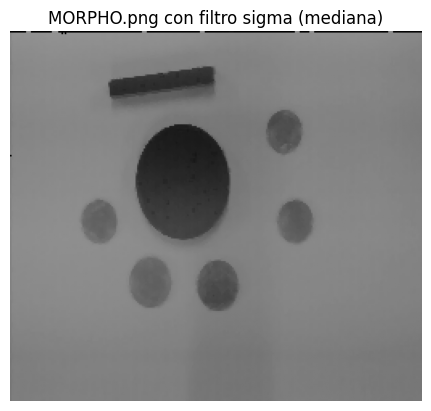

In [ ]:
# Filtro sigma con mediana activada
morpho_filtered_median = generic_filter(morpho_sp, sigma_filter, size=3, extra_arguments=(True,))

# Visualización de filtro sigma con mediana
plt.imshow(morpho_filtered_median, cmap='gray', vmin=0, vmax=255)
plt.title('MORPHO.png con filtro sigma (mediana)')
plt.axis('off')
plt.show()

**¿cómo es el resultado comparado con el filtro promedio lineal? explique este resultado.**

Observamos que el fondo permanece homogéneo y libre de manchas. A diferencia del promedio, esta variante no genera el efecto de "neblina" o desenfoque indiscriminado, permitiendo que la morfología de las piezas en morpho.png se mantenga definida.

Al utilizar la mediana como semilla, se rechazan los Outliers porque es estadísticamente probable que la mediana sea un valor representativo del nivel de gris real, no un pico de ruido (0 o 255). Además, el rango se centra en la señal verdadera porque los píxeles de ruido (sal y pimienta) quedan fuera de este intervalo (∣255−Imediana​∣≫Δ) y son excluidos del promedio final.

**En el caso del ruido “sal y pimienta”, después de aplicar el filtro Sigma, quedan varios sólo algunos aberrantes. ¿A qué se debe esto?**

Esto sucede debido a la corrupción de la mediana. Es decir, si en una vecindad local la densidad de ruido supera el 50%, el estadístico de la mediana colapsa y selecciona un valor ruidoso (0 o 255). Además, el filtro Sigma centra su rango en el ruido, preservando el punto aberrante o aplicando el valor de la mediana ruidosa como resultado.

**¿Por qué hay una diferencia significativa con el resultado anterior?**

La diferencia sustancial entre este resultado y el anterior (basado en el píxel central) radica en la estabilidad de la semilla. En la versión previa, si el píxel central era un punto de "sal", el filtro intentaba encontrar píxeles similares a 255 en su vecindad, fallando y preservando el ruido. Al cambiar la referencia a la mediana, el filtro recupera la capacidad de identificar el ruido como un elemento ajeno a la distribución local, logrando la eliminación de perturbaciones.

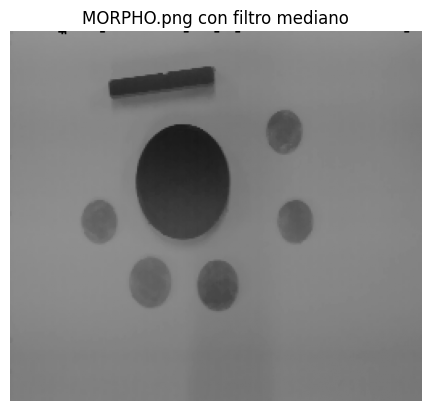

In [ ]:
# Filtro mediano de filters.rank
morpho_filtered_rank = median(morpho_sp, footprint=np.ones((3,3)))

# Visualización de filtro mediano
plt.imshow(morpho_filtered_rank, cmap='gray', vmin=0, vmax=255)
plt.title('MORPHO.png con filtro mediano')
plt.axis('off')
plt.show()

**¿cómo es el resultado comparado con los dos filtros anteriores?**

A diferencia de los tratamientos anteriores, este logra una restauración casi perfecta de la señal original, eliminando las perturbaciones sin degradar la nitidez de las estructuras.

**¿A qué se debe este resultado?**


* El ruido "sal y pimienta" consiste en valores extremos (0 o 255). Al ordenar los 9 píxeles de una vecindad de 3×3, estos valores se desplazan automáticamente a los extremos de la lista.

* Dado que el ruido es una minoría (incluso al 25%), la mediana será casi siempre un valor de intensidad representativo del objeto o del fondo, descartando los píxeles aberrantes de forma efectiva.

* A diferencia del promedio, que mezcla intensidades de ambos lados de un borde (creando borrosidad), la mediana elige un valor existente que pertenece a uno de los dos lados, manteniendo la transición abrupta y la nitidez del contorno.

/tmp/ipykernel_538/2720510544.py:4: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  footprint = square(3)


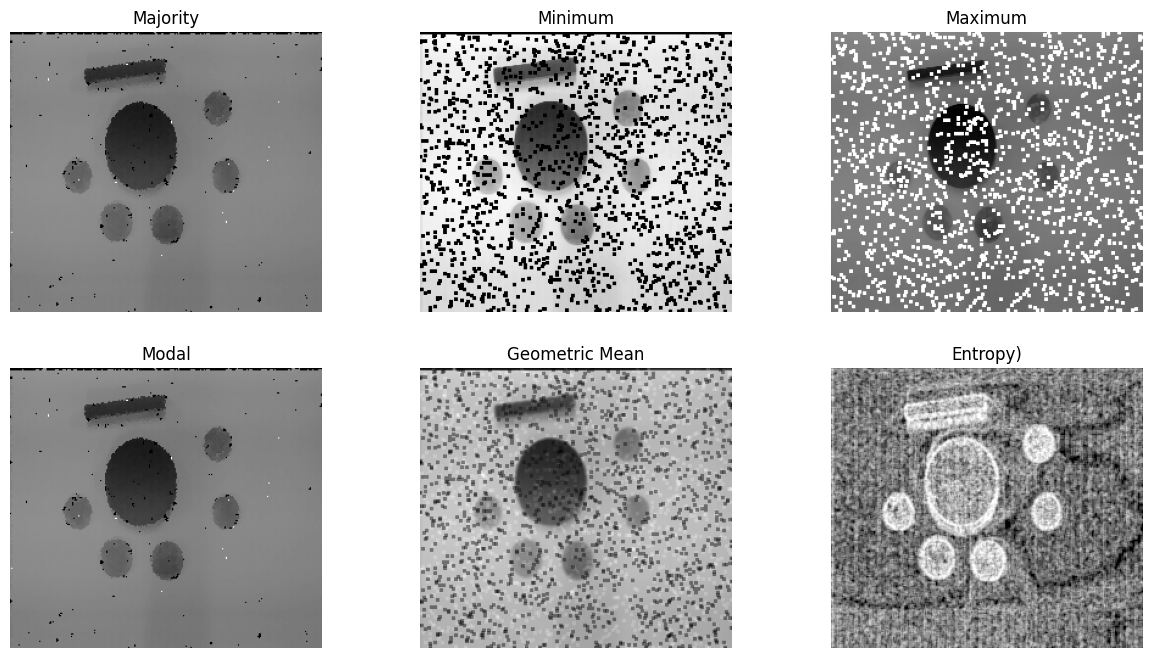

In [ ]:
# otros filtros que ofrece el módulo filters.rank

# Definición del footprint (equivalente a size=3)
footprint = square(3)

# Majority: Asigna el valor que aparece más veces
morpho_majority = majority(morpho_sp, footprint)

# Minimum: Erosión de niveles de gris
morpho_minimum = minimum(morpho_sp, footprint)

# Maximum: Dilatación de niveles de gris
morpho_maximum = maximum(morpho_sp, footprint)

# Modal: Similar a majority, busca el valor dominante
morpho_modal = modal(morpho_sp, footprint)

# Geometric Mean: Promedio geométrico
morpho_gmean = geometric_mean(morpho_sp, footprint)

# EXTRA: Entropy: Mide la complejidad local
morpho_entropy = entropy(morpho_sp, footprint)

# Visualización de otros filtros no lineales
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
titles = ['Majority', 'Minimum', 'Maximum', 'Modal', 'Geometric Mean', 'Entropy)']
images = [morpho_majority, morpho_minimum, morpho_maximum, morpho_modal, morpho_gmean, morpho_entropy]

for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout
plt.show()

* Minimum: Amplifica el ruido pimienta porque	basta un píxel 0 en la vecindad para "contaminar" el resultado.

* Maximum: Amplifica el ruido sal porque el valor 255 siempre es seleccionado como máximo.

* Majority: Asigna al píxel el valor que ocupa más del 50% de la vecindad, por lo que es efectivo para limpiar el ruido minoritario.

* Modal: Selecciona el valor con mayor frecuencia (la moda), por lo que logra eliminar gran parte del ruido S&P, pero puede generar parches de intensidad uniforme, eliminando texturas sutiles.

* Geometric Mean: da un	resultado pobre y oscuro por su extrema sensibilidad al valor 0; actúa como un suavizado asimétrico.

* Entropy: actúa como mapa de bordes/ruido, entonces las transiciones bruscas de ruido generan alta varianza estadística.

En conclusión, el filtro de mediana es el único operador de rango equilibrado. Los filtros Minimum y Maximum son útiles solo si se sabe que el ruido es de un solo tipo (solo sal o solo pimienta) y se aplica el opuesto (un minimum para eliminar sal), pero en ruido combinado S&P, solo logran empeorar la degradación en una de las dos polaridades.

### **Ruido Uniforme**

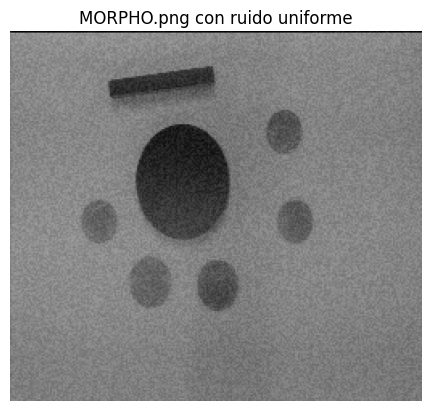

In [ ]:
# Definición de la amplitud
amplitud = 30
alpha = -amplitud / 2  # -15
beta = amplitud / 2    # 15

# Ruido uniforme sobre morpho
noise = np.random.uniform(low=alpha, high=beta, size=morpho.shape)
morpho_uniform = morpho + noise

# Es necesario truncar los valores al rango [0, 255]
morpho_uniform = np.clip(morpho_uniform, 0, 255).astype(np.uint8)

# Visualización del ruido uniforme
plt.imshow(morpho_uniform, cmap='gray', vmin=0, vmax=255)
plt.title('MORPHO.png con ruido uniforme')
plt.axis('off')
plt.show()

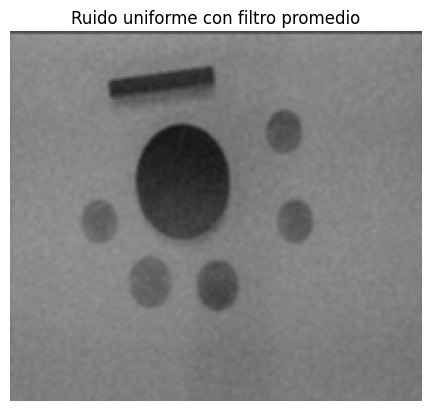

In [ ]:
# Filtro promedio para ruido uniforme
morpho_avg_uniform = mean(morpho_uniform, footprint_rectangle((3,3)))

# Visualización de filtro promedio
plt.imshow(morpho_avg_uniform, cmap='gray', vmin=0, vmax=255)
plt.title('Ruido uniforme con filtro promedio')
plt.axis('off')
plt.show()

**¿cómo es el resultado?**

Logramos observar que la "suciedad" o granulosidad que cubría uniformemente la imagen desaparece en gran medida, de hecho, el fondo gris se vuelve más homogéneo. Sin embargo, los contornos de las figuras geométricas pierden su definición abrupta, presentando una transición más suave (borrosa).

En comparación con el ruido S&P donde el promedio creaba manchas grises persistentes, aquí logra una restauración mucho más natural de los niveles de gris originales.

**¿a qué se debe?**

El ruido uniforme de amplitud 30 está centrado en cero (U[−15,15]), y al promediar 9 píxeles en una máscara de 3×3, las perturbaciones aleatorias positivas y negativas tienden a cancelarse entre sí.

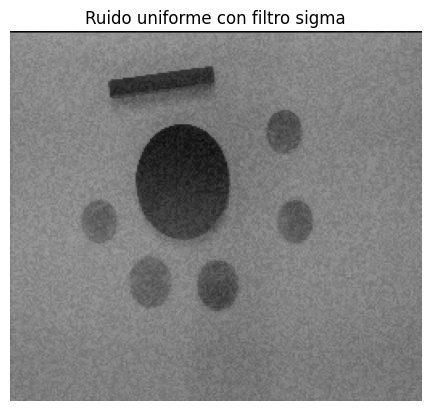

In [ ]:
# Filto sigma para ruido uniforme
morpho_filtered_uniform = generic_filter(morpho_uniform, sigma_filter, size=3)

# Visualización de filtro sigma uniforme
plt.imshow(morpho_filtered_uniform, cmap='gray', vmin=0, vmax=255)
plt.title('Ruido uniforme con filtro sigma')
plt.axis('off')
plt.show()
plt.show()

**¿cómo es el resultado comparado con el filtro promedio lineal?**

Observamos que el resultado del filtro Sigma presenta un fondo más limpio que la imagen ruidosa original. Comparado con un promedio lineal, los bordes de los círculos y el rectángulo en la parte superior no se ven tan borrosos, manteniendo una separación más clara entre el objeto y el fondo.

**Consultando la definición del Sigma explique este resultado**

En las áreas de fondo de MORPHO.png, las variaciones producidas por el ruido uniforme (±15 niveles) son pequeñas. Si el umbral Δ es mayor a 15, el filtro Sigma incluye a todos los píxeles de la vecindad en el promedio.

Cuando la ventana cruza un borde, los píxeles del lado opuesto tienen una intensidad significativamente distinta a Ic​. La diferencia excede el umbral Δ:
$$∣I(i,j)−Ic​∣$$

Por lo que, estos píxeles son excluidos del cálculo y el promedio se calcula solo con píxeles que pertenecen al mismo objeto que el centro, evitando que la intensidad del fondo "contamine" al objeto y viceversa.

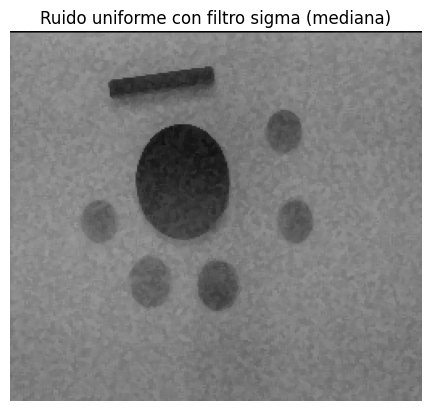

In [ ]:
# Filtro sigma con median para uniforme
morpho_filtered_uniform_median = generic_filter(morpho_uniform, sigma_filter, size=3, extra_arguments=(True,))

# Visualización de filtro sigma con mediana
plt.imshow(morpho_filtered_uniform_median, cmap='gray', vmin=0, vmax=255)
plt.title('Ruido uniforme con filtro sigma (mediana)')
plt.axis('off')
plt.show()

**¿cómo es el resultado comparado con el filtro promedio lineal?**

Mientras que el filtro promedio lineal genera una rampa de difuminado (blur) en las transiciones entre objetos y fondo, el filtro Sigma-mediana mantiene la nitidez de los contornos. En la imagen procesada, los círculos y el rectángulo superior conservan una definición geométrica nítida, libre de desenfoque característico de los filtros lineales.

**Consultando la definición del Sigma explique este resultado**

Al centrar el intervalo Sigma en la mediana, se asegura que el rango de promediado esté alineado con la señal real y no con una fluctuación aleatoria del ruido. Aunque el ruido uniforme no es impulsivo, cualquier valor extremo ocasional es ignorado por la mediana, lo que garantiza que la "ventana de aceptación" del filtro sea siempre óptima para la restauración de la imagen MORPHO.png.

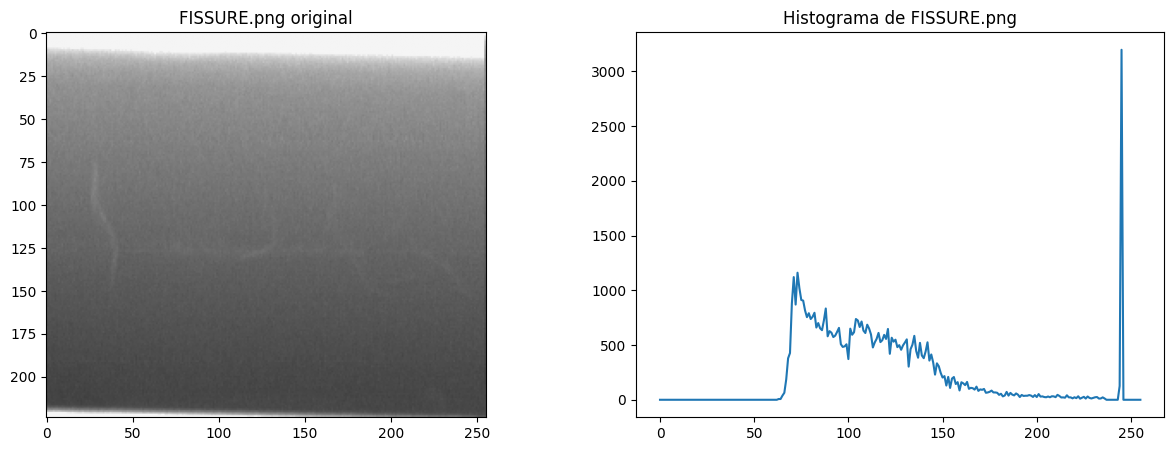

In [ ]:
# Carga de fissure.png
fissure = cv2.imread('images/FISSURE.png', cv2.IMREAD_GRAYSCALE)

# Histograma de fissure.png
hist_fissure = cv2.calcHist([fissure], [0], None, [256], [0, 256])

# Visualización de fissure y su hist
fig_fissure, ax_fissure = plt.subplots(1, 2, figsize=(15,5))
ax_fissure[0].imshow(fissure, cmap='gray', vmin=0, vmax=255)
ax_fissure[0].set_title('FISSURE.png original')
ax_fissure[1].plot(hist_fissure)
ax_fissure[1].set_title('Histograma de FISSURE.png')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: UserWarning: Possible precision loss converting image of type float64 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  exec(code_obj, self.user_global_ns, self.user_ns)


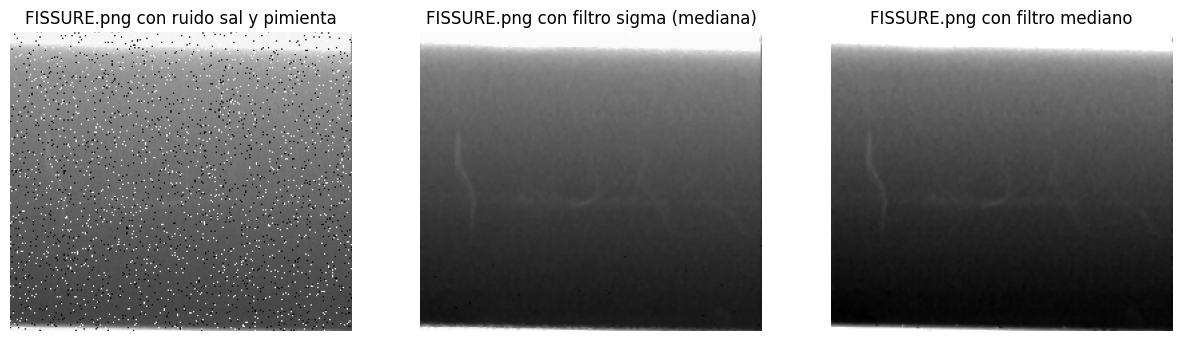

In [ ]:
# Ruido sal y pimienta en fissure
fissure_sp = random_noise(fissure, mode='s&p', amount=0.05)

# Filto sigma mediano
fissure_filtered_median = generic_filter(fissure_sp, sigma_filter, size=3, extra_arguments=(True,))

# Filtro mediano original
fissure_median = median(fissure_sp, footprint=np.ones((3,3)))

# Visualización
fig_fissure_sp, ax_fissure_sp = plt.subplots(1, 3, figsize=(15,5))
ax_fissure_sp[0].imshow(fissure_sp, cmap='gray')
ax_fissure_sp[0].set_title('FISSURE.png con ruido sal y pimienta')
ax_fissure_sp[0].axis('off')
ax_fissure_sp[1].imshow(fissure_filtered_median, cmap='gray')
ax_fissure_sp[1].set_title('FISSURE.png con filtro sigma (mediana)')
ax_fissure_sp[1].axis('off')
ax_fissure_sp[2].imshow(fissure_median, cmap='gray')
ax_fissure_sp[2].set_title('FISSURE.png con filtro mediano')
ax_fissure_sp[2].axis('off')
plt.show()

**Filtro Sigma con Semilla de Mediana**

Observamos que el ruido desaparece casi por completo (aunque se ven algunos puntos pimienta en la parte inferior) y el fondo recupera homogeneidad. También, las fisuras son visibles como líneas suaves.

Al usar la mediana como referencia, el filtro ignora los puntos de ruido al establecer el rango de búsqueda. El filtro solo promedia píxeles "sanos" (cercanos a la mediana), excluyendo quirúrgicamente los valores 0 y 255.

En conclusión, se logra una limpieza superior al promedio lineal al no permitir que el ruido contamine los píxeles vecinos.

**Filtro Mediano Estándar**

Este muestra un resultado muy similar al Sigma-mediana, eliminando la totalidad de los puntos aberrantes, pero oscureciendo más la imagen.

El filtro ordena los valores del vecindario y selecciona el central, como el ruido ocupa los extremos (0 y 255), es descartado automáticamente.

A diferencia de los filtros basados en promedios, la mediana mantiene mejor la acutancia (nitidez) de las fisuras, evitando el desenfoque excesivo.

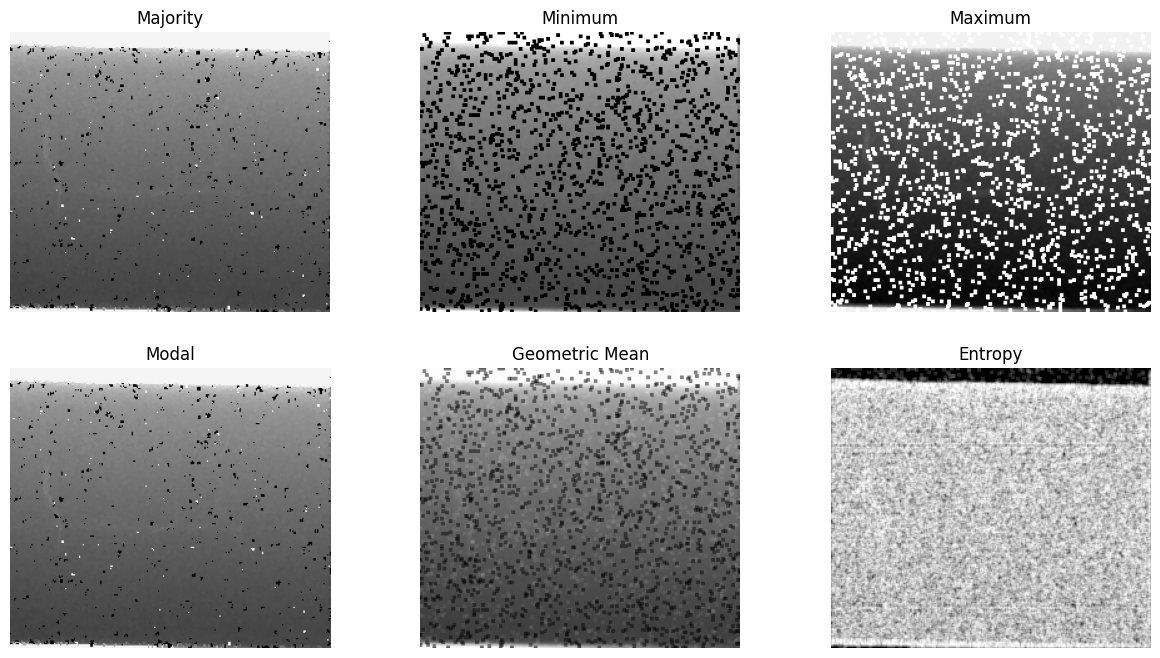

In [ ]:
# Otros filtros de risk

# Majority
fissure_majority = majority(fissure_sp, footprint=np.ones((3,3)))

# Minimum
fissure_minimum = minimum(fissure_sp, footprint=np.ones((3,3)))

# Maximum
fissure_maximum = maximum(fissure_sp, footprint=np.ones((3,3)))

# Modal
fissure_modal = modal(fissure_sp, footprint=np.ones((3,3)))

# Geometric Mean
fissure_gmean = geometric_mean(fissure_sp, footprint=np.ones((3,3)))

# Entropy
fissure_entropy = entropy(fissure_sp, footprint=np.ones((3,3)))

# Visualización de otros

fig_others, ax_others = plt.subplots(2, 3, figsize=(15, 8))
ax_others[0, 0].imshow(fissure_majority, cmap='gray')
ax_others[0, 0].set_title('Majority')
ax_others[0, 0].axis('off')

ax_others[0, 1].imshow(fissure_minimum, cmap='gray')
ax_others[0, 1].set_title('Minimum')
ax_others[0, 1].axis('off')

ax_others[0, 2].imshow(fissure_maximum, cmap='gray')
ax_others[0, 2].set_title('Maximum')
ax_others[0, 2].axis('off')

ax_others[1, 0].imshow(fissure_modal, cmap='gray')
ax_others[1, 0].set_title('Modal')
ax_others[1, 0].axis('off')

ax_others[1, 1].imshow(fissure_gmean, cmap='gray')
ax_others[1, 1].set_title('Geometric Mean')
ax_others[1, 1].axis('off')

ax_others[1, 2].imshow(fissure_entropy, cmap='gray')
ax_others[1, 2].set_title('Entropy')
ax_others[1, 2].axis('off')

plt.tight_layout
plt.show()

**Conclusión en qué casos se usan cada uno de estos filtros**

* Sigma (con semilla de Mediana): sirve para la limpieza profunda que además suavice la textura del fondo porque combina la robustez de la mediana con un promediado selectivo que homogeniza el fondo de la imagen de forma muy efectiva.

* Median: es la opción preferida para eliminar ruido impulsivo ("sal y pimienta") porque ofrece el equilibrio perfecto al eliminar tanto puntos blancos como negros sin destruir la nitidez de las fisuras.

* Minimum: Sirve para expandir objetos oscuros o reducir objetos brillantes porque vemos que en esta imagen se amplifica el ruido "pimienta", ocultando las fisuras bajo manchas negras expandidas.

* Maximum: Sirve para expandir regiones brillantes o rellenar huecos oscuros pequeños porque vemos que en esta imagen se amplifica el ruido "sal", creando bloques blancos que saturan la imagen.

* Majority/Modal:	Sirve para limpiar ruido impulsivo leve o en imágenes ya segmentadas (etiquetadas) porque eliminan gran parte del ruido, pero en densidades del 25% dejan rastros donde el ruido estaba muy concentrado.

* Geometric Mean:	Sirve en modelos de ruido específicos (como el ruido Gaussiano) donde no haya valores de cero absoluto. Sin embargo, es inútil contra el ruido "pimienta" porque cualquier valor $0$ en la ventana anula el producto, resultando en una imagen oscura y muy degradada.

* Entropy: Sirve para segmentación por textura o detección de bordes en ambientes muy ruidosos porque realmente NO limpia la imagen. De hecho, genera un mapa de la "incertidumbre" local, resaltando las fisuras y el ruido como zonas de alta complejidad estadística.

## **Ejercicio de síntesis**

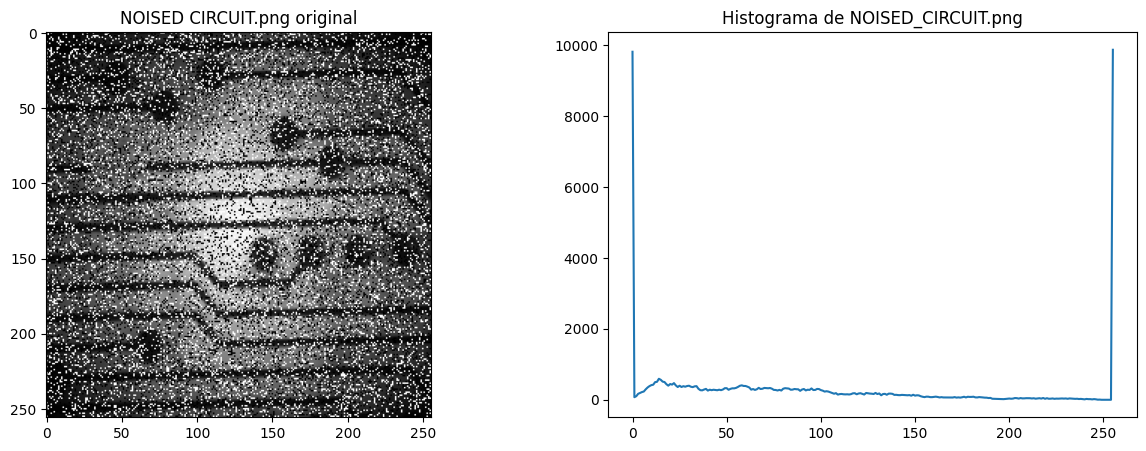

In [ ]:
# Carga de circuit.png
circuit = cv2.imread('images/NOISED_CIRCUIT.png', cv2.IMREAD_GRAYSCALE)

# Histograma de circuit
hist_noised_circuit = cv2.calcHist([circuit], [0], None, [256], [0, 256])

# Visualización de la imagen
fig_noised_circuit, ax_noised_circuit = plt.subplots(1, 2, figsize=(15, 5))
ax_noised_circuit[0].imshow(circuit, cmap='gray', vmin=0, vmax=255)
ax_noised_circuit[0].set_title('NOISED CIRCUIT.png original')
ax_noised_circuit[1].plot(hist_noised_circuit)
ax_noised_circuit[1].set_title('Histograma de NOISED_CIRCUIT.png')
plt.show()

In [ ]:
def filtro_mediano_adaptativo(image, s_max):
    # Imagen de salida y dimensiones
    rows, cols = image.shape
    out_img = np.zeros_like(image)

    # Padding para manejar bordes (espejo)
    pad_size = s_max // 2
    padded_img = cv2.copyMakeBorder(image, pad_size, pad_size, pad_size, pad_size, cv2.BORDER_REFLECT)

    for i in range(rows):
        for j in range(cols):
            # i, j están desplazados en la imagen con padding
            curr_i, curr_j = i + pad_size, j + pad_size
            z_xy = padded_img[curr_i, curr_j]

            s = 3  # Tamaño inicial de ventana
            while s <= s_max:
                half_s = s // 2
                window = padded_img[curr_i - half_s : curr_i + half_s + 1,
                                    curr_j - half_s : curr_j + half_s + 1]

                z_min = np.min(window)
                z_max = np.max(window)
                z_med = np.median(window)

                # --- ETAPA A ---
                a1 = z_med - z_min
                a2 = z_med - z_max

                if a1 > 0 and a2 < 0:
                    # Pasamos a ETAPA B
                    b1 = z_xy - z_min
                    b2 = z_xy - z_max
                    if b1 > 0 and b2 < 0:
                        out_img[i, j] = z_xy # Píxel original válido
                    else:
                        out_img[i, j] = z_med # Píxel era ruido
                    break # Salimos del while
                else:
                    # La mediana es ruido, expandir ventana
                    s += 2

                # Si llegamos al límite Smax, devolvemos la última mediana
                if s > s_max:
                    out_img[i, j] = z_med

    return out_img

/tmp/ipykernel_538/4709646.py:33: RuntimeWarning: overflow encountered in scalar subtract
  b2 = z_xy - z_max


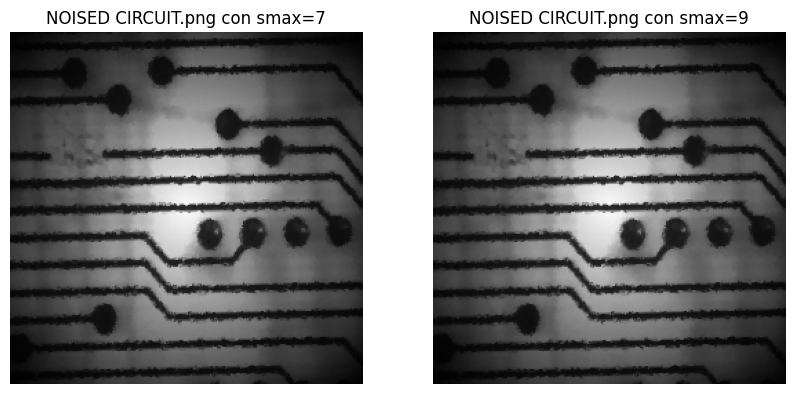

In [ ]:
# Conversión a imagen de 16 bits
circuit = circuit.astype(np.uint16)

# Aplicación del filtro a la imagen ruidosa
circuit_restored7 = filtro_mediano_adaptativo(circuit, s_max=7)
circuit_restored9 = filtro_mediano_adaptativo(circuit, s_max=9)

# Reconversión a 8 bits
circuit_restored7 = circuit_restored7.astype(np.uint8)
circuit_restored9 = circuit_restored9.astype(np.uint8)

# Visualización de circuit con diferentes smax
fig_circuit, ax_circuit = plt.subplots(1, 2, figsize=(10, 5))
ax_circuit[0].imshow(circuit_restored7, cmap='gray', vmin=0, vmax=255)
ax_circuit[0].set_title('NOISED CIRCUIT.png con smax=7')
ax_circuit[0].axis('off')
ax_circuit[1].imshow(circuit_restored9, cmap='gray', vmin=0, vmax=255)
ax_circuit[1].set_title('NOISED CIRCUIT.png con smax=9')
ax_circuit[1].axis('off')
plt.show()

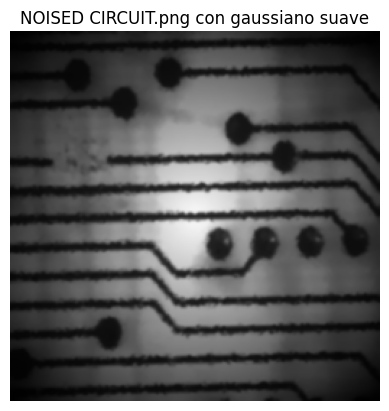

In [ ]:
#Aplicamos un Gaussiano muy suave para alisar los bordes de "escalera" que dejó el filtro mediano.
circuit_smoothed = gaussian_filter(circuit_restored7, sigma=0.8)

# Visualización del gaussiano suave
plt.imshow(circuit_smoothed, cmap='gray', vmin=0, vmax=255)
plt.title('NOISED CIRCUIT.png con gaussiano suave')
plt.axis('off')
plt.show()

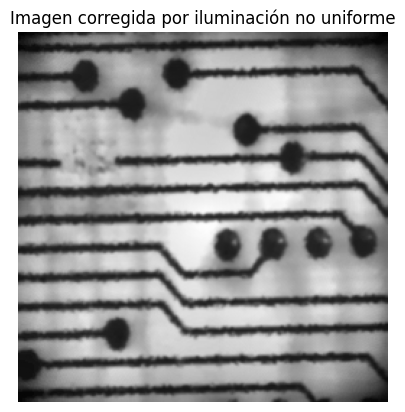

In [ ]:
from scipy.ndimage import gaussian_filter

background = gaussian_filter(circuit_smoothed, sigma=30)

corrected = circuit_smoothed / background

corrected = (corrected - corrected.min()) / (corrected.max() - corrected.min())

plt.imshow(corrected, cmap='gray')
plt.title("Imagen corregida por iluminación no uniforme")
plt.axis('off')
plt.show()

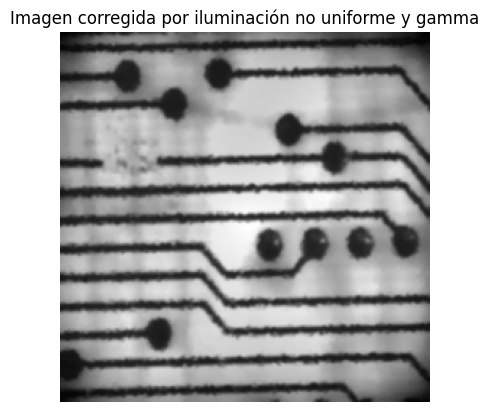

In [ ]:
# Reescalado con GAMMA
circuit_rescaled = exposure.rescale_intensity(corrected, in_range=(0,1), out_range=(0, 255)).astype(np.uint8)
fin = exposure.adjust_gamma(corrected, gamma=1)

plt.imshow(fin, cmap='gray')
plt.title("Imagen corregida por iluminación no uniforme y gamma")
plt.axis('off')
plt.show()